In [164]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

In [165]:
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=8
)

val_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=8
)

test_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=8
)

Found 104 files belonging to 2 classes.


Found 21 files belonging to 2 classes.
Found 25 files belonging to 2 classes.


In [166]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2)
    ]
)

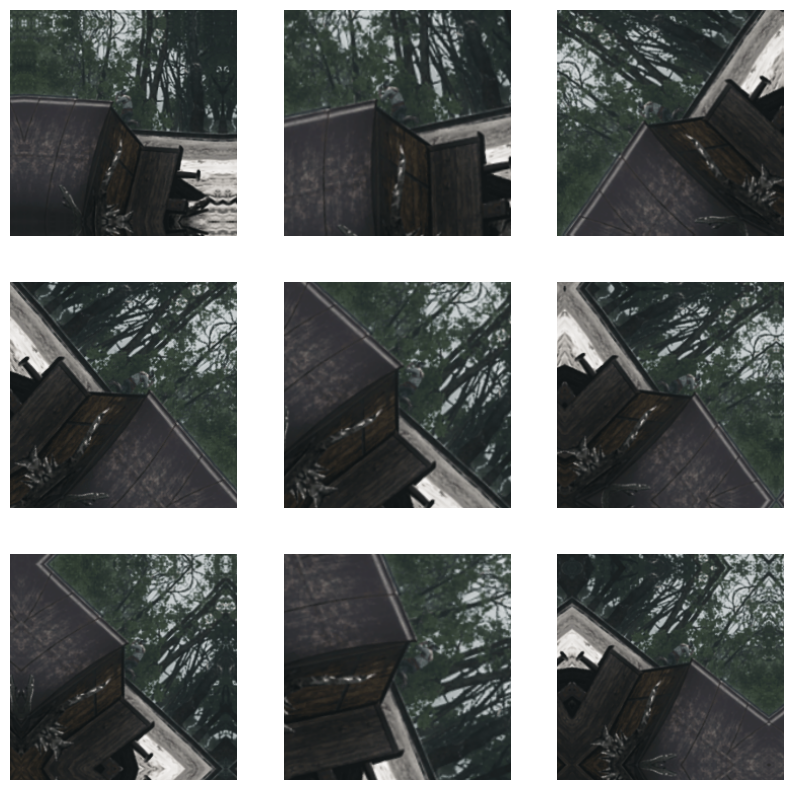

In [167]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [168]:
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0/255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_12 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │        25,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,004,097 (3.83 MB)

 Trainable params: 1,004,097 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [169]:
opt = keras.optimizers.RMSprop(learning_rate=0.0001)

model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

In [170]:
for data_batch, labels_batch in train_ds:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (8, 224, 224, 3)
labels batch shape: (8,)


In [171]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

callbacks = [keras.callbacks.ModelCheckpoint(
    filepath = "convnet_from_scratch_with_augmentation.keras",
    save_best_only = True,
    monitor = "val_loss"),
    early_stopping]

In [172]:
history = model.fit(
    train_ds,
    epochs = 50,
    validation_data = val_ds,
    callbacks = callbacks)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.3365 - loss: 0.7001 - val_accuracy: 0.4762 - val_loss: 0.6942
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4808 - loss: 0.6920 - val_accuracy: 0.4762 - val_loss: 0.6945
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4808 - loss: 0.6933 - val_accuracy: 0.4762 - val_loss: 0.6942
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4808 - loss: 0.6915 - val_accuracy: 0.4762 - val_loss: 0.6957
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4808 - loss: 0.6887 - val_accuracy: 0.4762 - val_loss: 0.6928
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.4904 - loss: 0.6902 - val_accuracy: 0.4762 - val_loss: 0.6923
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5096 - loss: 0.6891 - val_accuracy: 0.4762 - val_loss: 0.6899
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.5385 - loss: 0.6915 - val_accuracy: 0.6190 -

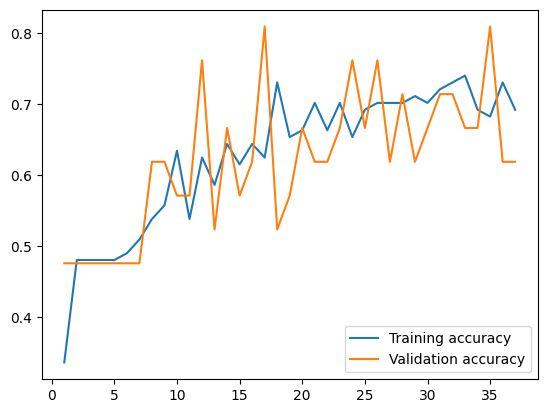

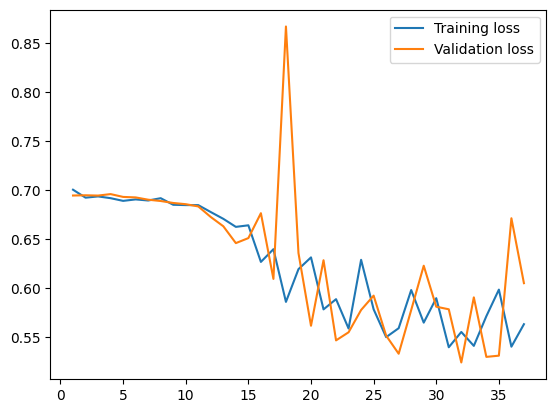

In [173]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [174]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6800 - loss: 0.6211
Test accuracy: 0.680


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


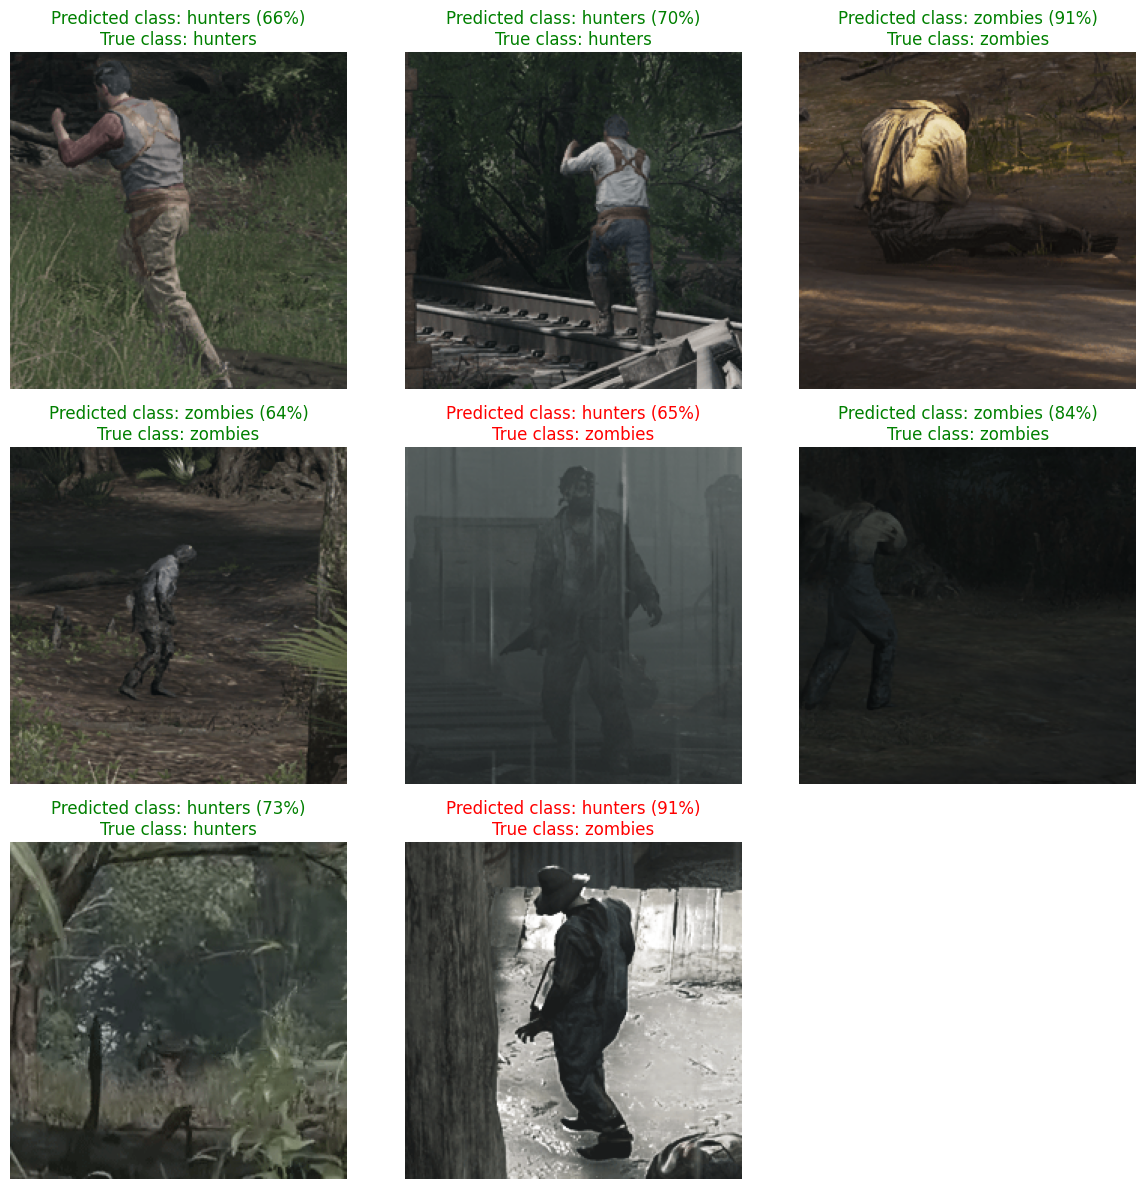

In [176]:
class_names = test_ds.class_names

for images, labels in test_ds.take(1):
    preds = test_model.predict(images)

    plt.figure(figsize=(12, 12))

    for i in range(len(images)):
        ax = plt.subplot(3, 3, i + 1)
        img = images[i].numpy().astype("uint8")

        plt.imshow(img)

        prob = preds[i][0]
        
        if prob > 0.5:
            predicted_label = 1
            prob = prob
        else:
            predicted_label = 0
            prob = 1 - prob

        title = f"Predicted class: {class_names[predicted_label]} ({prob*100:.0f}%)\nTrue class: {class_names[labels[i]]}"

        color = "green" if predicted_label == labels[i] else "red"

        plt.title(title, color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()